# Stats 102B Homework 1

## **Author:** Bosen Yang

# PROBLEM 1

## Part a)
$f(x)=x^4+2x^2+1$, 
$f'(x)=4x^3+4x$, 
$f''(x)=12x^2+4$

Set $f'(x)=0 \Rightarrow 4x^3+4x=0 \Rightarrow 4x(x^2+1)=0 \Rightarrow x=0, \pm i$

Then x = 0 is a critical point.

Since $f''(0)=4$, then f(x) concaves up at $x=0$, so $x=0$ is a minimum.

## Part b) (Code refer to Appendix 1.b)

**Code Outputs:**
- The minimum by constant step size with x0 = 2 is 0.0
- The minimum by constant step size with x0 = 5 is nan
- The minimum by backtracking with x0 = 2 is -6.352747104407253e-22
- The minimum by backtracking with x0 = 5 is 6.117402889587939e-12

## 1. Step Size Selection

For choosing constant step size, step size $\eta$ selection is based on the Lipschitz Constant L of the function, and $\eta$ shall not exceed $\frac{2}{L}$. Typically picking $\eta \leq \frac{1}{L}$ ensures convergence. In practice, I start trying from large step size and shrink it until it converges. Meanwhile, I should also not making it too small for sake of convergence rate.

In addition, we cannot always use the same step size for $x_0 = 2$ and $x_0 = 5$. If we pick step size to be $\eta = 0.05$, for $x_0 = 2$, it converges in 1 iteration; but for $x_0 = 5$, it overshoots and diverges rapidly. On the other hand, $\eta = 0.01$ works for both initial points but it takes more than 1000 iterations for those to converge. 

## 2. Convergence Plot (Code and Plots refer to Appendix 1.b.2)

#### Conclusion
- The minimum is $x^*=0$ and $f(x^*)=1$.
- Notice that Backtracking for $x_0=2$ and $x_0=5$ converges in $5$ and $4$ iterations with initial step size $\eta_{init}=0.5$.  
- Constant step size $\eta = 0.05$ converges for $x_0=2$ in $1$ iteration, but diverges for $x_0=5$

## 3. Dynamic Step Size Plot (Code and Plots refer to Appendix 1.b.3) 

#### Conclusion
- The step sizes increase as the algorithm approaches the minimum
- At the beginning, the gradient is huge so large step size may overshoot badly. Therefore the step size is shrinked by Armijo condition.
- As the algorithm more approach to the minimum, the gradient becomes smaller and larger step sizes is safer.

# PROBLEM 2

## Part a) (Code refer to Appendix 2.a)

**The Squared Error Loss is given as**

$$f(\beta)=\frac{1}{2m}\|y-X\beta\|_2^2=\frac{1}{2m}(y-X\beta)^T\cdot(y-X\beta)=\frac{1}{2m} \cdot (y^Ty+\beta^TX^TX\beta-2\beta^TX^Ty)$$

**Its gradient is**

$$\nabla f(\beta)=\frac{1}{m}(X^TX\beta-X^Ty)=-\frac{1}{m}X^T(y-X\beta)$$

**Its Hessian is (Denotes Q)**

$$Q = \nabla^2 f(\beta)=\frac{1}{m}X^TX$$

## 1. Step Size

#### **Constant Step Size Selection**:

My methodology to select good step size by applying empirically methods. I start off from a large step size and gradually decrease it until the algorithm converges stably. Meanwhile, I also refer to the slope rate of change in the convergence plot, and decide which step size gives better convergence rates and numerical stability.

#### **Convergence Criterion:** 

Since the squared loss function is convex and L-smooth, then the convergence criterion for step size $\eta$ is given as

$$0<\eta<\frac{2}{L}$$

where $L$ is the Lipschitz constant satisfying $\|\nabla f(x) - \nabla f(y)\|_2 \leq L\|x-y\|_2$ for $\forall x,y \in \mathbb{R}^n$. For this squared loss function $f(\beta)$ (Quadratic), $L=\lambda_{max}(Q) = \lambda_{max}(\frac{X^TX}{m})$

#### **Tolerance Parameter:**

I employed `1-e4` as the tolerance parameter and set stop criterion to be: stop when  $\|\nabla f(\beta)\|_2 < tol$. 

## 2. Accuracy Comparison (Code refer to Appendix 2.a.2)

$$\|\beta_{GD} - \beta_{OLS}\|_2$$

**Code Outputs**
- The L2 error for dataset1 with constant step size is **0.08802567073568018** with **1300** iterations
- The L2 error for dataset1 with backtracking is **0.08778907235868703** with **728** iterations
- The L2 error for dataset2 with constant step size is **0.08712829167363445** with **1493** iterations
- The L2 error for dataset2 with backtracking is **0.0849918670178052** with **1085** iterations

## 3. Convergence Plot (Code refer to Appendix 2.a.3)

#### Conclusion

- both methods for both datasets all converges to the mininum value of the square loss function
- Backtracking method converges with a much fewer iterations than a "good pick" of constant step size

## Part b) (Code refer to Appendix 2.b)

## 1. Accuracy Comparison (Code refer to Appendix 2.b.1)

**Code Outputs**

**Constant Step Size:**
- The L2 error for dataset1 with Polyak's Heavy Ball (const) is **0.08507937711790518** with **41** iterations
- The L2 error for dataset1 with Nesterov's Accelerated Gradient (const) is **0.08703224544992047** with **72** iterations
- The L2 error for dataset2 with Polyak's Heavy Ball (const) is **0.08727904174989319** with **494** iterations
- The L2 error for dataset2 with Nesterov's Accelerated Gradient (const) is **0.08731438059971773** with **1751** iterations

**Backtracking:**
- The L2 error for dataset1 with Polyak's Heavy Ball (backtracking) is **0.0880311266271821** with **360** iterations
- The L2 error for dataset1 with Nesterov's Accelerated Gradient (backtracking) is **0.0879291715609226** with **582** iterations
- The L2 error for dataset2 with Polyak's Heavy Ball (backtracking) is **0.06584813324503602** with **888** iterations
- The L2 error for dataset2 with Nesterov's Accelerated Gradient (backtracking) is **0.0807405381699661** with **1029** iterations

## 2. Convergence Plot (Code refer to Appendix 2.b.2)

#### Conclusion

- Nesterov's Momentum method outperform the classical gradient descent method in some situations, but not always. Compared with Ployak's Heavy Ball method, Nesterov's Momentum method even converges slower in both datasets.

## 3. Findings

#### Dataset 1

- **Gradient Descent**
  - Constant: (Error = 0.08803, Iter = 1300)  
  - Backtracking: (Error = 0.08779, Iter = 728)

- **Heavy Ball**
  - Constant: (Error = 0.08508, Iter = 41)  
  - Backtracking: (Error = 0.08803, Iter = 360)

- **Nesterov**
  - Constant: (Error = 0.08703, Iter = 72)  
  - Backtracking: (Error = 0.08793, Iter = 582)

#### Dataset 2

- **Gradient Descent**
  - Constant: (Error = 0.08713, Iter = 1493)  
  - Backtracking: (Error = 0.08499, Iter = 1085)

- **Heavy Ball**
  - Constant: (Error = 0.08728, Iter = 494)  
  - Backtracking: (Error = 0.06585, Iter = 888)

- **Nesterov**
  - Constant: (Error = 0.08731, Iter = 1751)  
  - Backtracking: (Error = 0.08074, Iter = 1029)

**Conclusion:** In general, momentum method does take fewer iterations than classical gradient descent method, but this does not always happen. Those methods all reaches to the same level of accuracy in finite number of iterations, however if they would have the same number of iterations, momentum methods in general can reaches to higher accuracy.

---

# Appendix

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# PROBLEM 1 - CODE

---

## CODE (1.b)

In [143]:
# Object Function f(x) = x^4 + 2x^2 + 1
fcn = np.poly1d([1, 0, 2, 0, 1])

In [144]:
# CONSTANT STEP SIZE
def gradient_descent_const(fcn, x0, step_size):
    # Tuning Parameters
    tol = 1e-8
    
    # Initial values
    x = x0
    fcn_prime = fcn.deriv()
    num_iter = 0
    points = [x]
    
    while num_iter < 50:  
        # COMPUTE SLOPE
        slope = fcn_prime(x)
        
        # STOP CRITERION
        if abs(slope) < tol:
            break
        if np.isnan(x) or np.isinf(x): # Stop if diverges
            break
        
        # INCREMENT
        num_iter += 1
        
        # COMPUTE NEW POINT
        x = x - step_size * slope
        points.append(x)

    return {"value": x, "points": points}

In [145]:
# BACKTRACKING LINE SEARCH
def gradient_descent_backtracking(fcn, x0):
    # Tuning Parameters
    tol = 1e-8
    epsilon = 0.25
    tau = 0.5
    
    # Initial values
    x = x0
    fcn_prime = fcn.deriv()
    num_iter = 0
    points = [x]
    step_sizes = []
    
    while num_iter < 50: 
        # COMPUTE SLOPE
        slope = fcn_prime(x)
        
        # STOP CRITERION
        if abs(slope) < tol:
            break
        if np.isnan(x) or np.isinf(x): # Stop if diverges
            break

        # INCREMENT
        num_iter += 1
        
        # RESET STEP SIZE
        step_size = 0.5
        
        # UPDATE (Armijo Condition)
        while fcn(x - step_size * slope) > fcn(x) - epsilon * step_size * slope**2:
            step_size = tau * step_size
        step_sizes.append(step_size)
        
        # COMPUTE NEW POINT
        x = x - step_size * slope
        points.append(x)

    return {"value": x, "points": points, "step sizes": step_sizes}

In [146]:
# FUNCTION CALLING AND OUTPUTS

const_set_2 = gradient_descent_const(fcn, 2, 0.05)
const_val_2 = const_set_2["value"]
const_points_2 = const_set_2["points"]

const_set_5 = gradient_descent_const(fcn, 5, 0.05)
const_val_5 = const_set_5["value"]
const_points_5 = const_set_5["points"]

backtracking_set_2 = gradient_descent_backtracking(fcn, x0 = 2)
backtracking_val_2 = backtracking_set_2["value"]
backtracking_points_2 = backtracking_set_2["points"]
backtracking_steps_2 = backtracking_set_2["step sizes"]

backtracking_set_5 = gradient_descent_backtracking(fcn, x0 = 5)
backtracking_val_5 = backtracking_set_5["value"]
backtracking_points_5 = backtracking_set_5["points"]
backtracking_steps_5 = backtracking_set_5["step sizes"]

print(f"The minimum by constant step size 0.05 with x0 = 2 is {const_val_2}")
print(f"The minimum by constant step size 0.05 with x0 = 5 is {const_val_5}")
print(f"The minimum by backtracking with x0 = 2 is {backtracking_val_2}")
print(f"The minimum by backtracking with x0 = 5 is {backtracking_val_5}")

The minimum by constant step size 0.05 with x0 = 2 is 0.0
The minimum by constant step size 0.05 with x0 = 5 is -inf
The minimum by backtracking with x0 = 2 is -6.352747104407253e-22
The minimum by backtracking with x0 = 5 is 6.117402889587939e-12


C:\Users\30682\anaconda3\envs\16A\lib\site-packages\numpy\lib\_polynomial_impl.py:769: RuntimeWarning: overflow encountered in multiply
  y = y * x + pv
C:\Users\30682\anaconda3\envs\16A\lib\site-packages\numpy\lib\_polynomial_impl.py:769: RuntimeWarning: invalid value encountered in multiply
  y = y * x + pv


---

## CODE (1.b.2)

C:\Users\30682\anaconda3\envs\16A\lib\site-packages\numpy\lib\_polynomial_impl.py:769: RuntimeWarning: invalid value encountered in multiply
  y = y * x + pv
C:\Users\30682\anaconda3\envs\16A\lib\site-packages\numpy\lib\_polynomial_impl.py:769: RuntimeWarning: overflow encountered in multiply
  y = y * x + pv


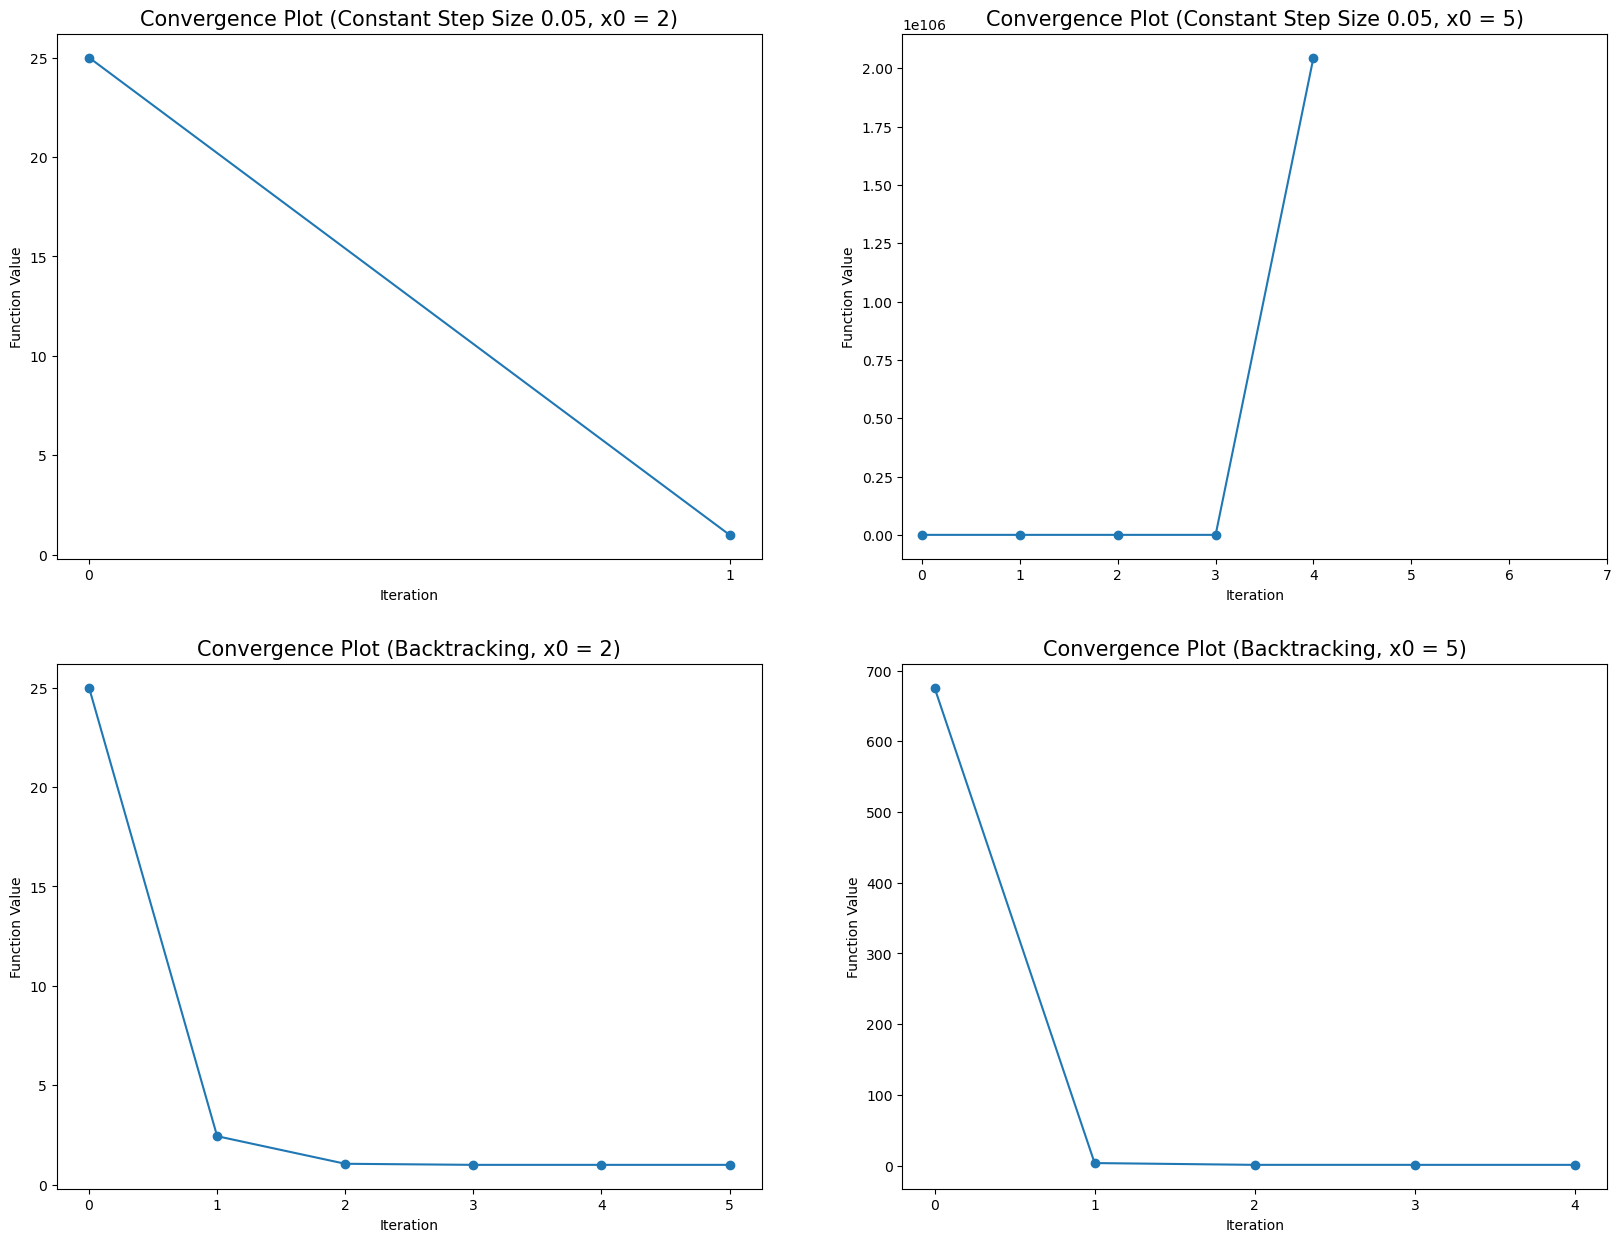

In [147]:
# Convergence Plot
# 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

titles = [
    "Convergence Plot (Constant Step Size 0.05, x0 = 2)",
    "Convergence Plot (Constant Step Size 0.05, x0 = 5)",
    "Convergence Plot (Backtracking, x0 = 2)",
    "Convergence Plot (Backtracking, x0 = 5)"
]

all_outputs = [
    fcn(const_points_2),
    fcn(const_points_5),
    fcn(backtracking_points_2),
    fcn(backtracking_points_5)
]

for ax, title, outputs in zip(axes.flatten(), titles, all_outputs):
    
    x_vals = list(range(len(outputs)))  # iterations
    ax.plot(x_vals, outputs, marker='o')
    
    ax.set_title(title,fontsize=15)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Function Value")
    ax.set_xticks(x_vals)
    
plt.show()

---

## CODE (1.b.3)

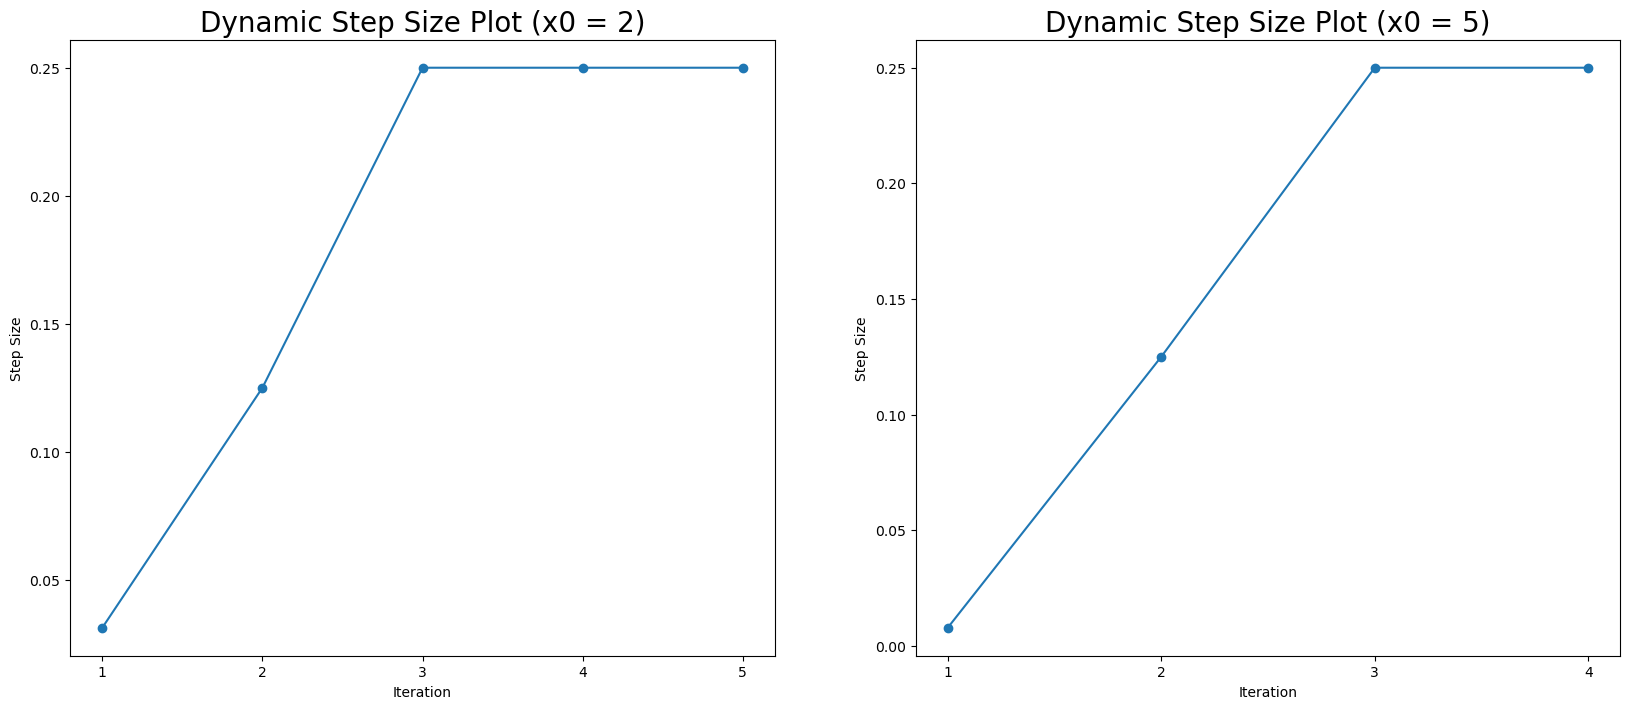

In [148]:
# Dynamic Step Size Plot
# 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

titles_2 = [
    "Dynamic Step Size Plot (x0 = 2)",
    "Dynamic Step Size Plot (x0 = 5)"
]

all_outputs_2 = [
    backtracking_steps_2,
    backtracking_steps_5
]

for ax, title, outputs in zip(axes.flatten(), titles_2, all_outputs_2):
    
    x_vals = list(range(1, len(outputs) + 1))  # iterations
    ax.plot(x_vals, outputs, marker='o')
    
    ax.set_title(title, fontsize=20)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Step Size")
    ax.set_xticks(x_vals)
    
plt.show()

---

# PROBLEM 2 - CODE

In [149]:
#### --- DEFINE FUNCTIONS --- ####

def norm2(v):  # Euclidean norm
    v = np.asarray(v)
    return np.sqrt(np.sum(v ** 2))

def loss_fcn(X, y, beta):  # Objective Function (Square loss)
    return (1 / (2 * X.shape[0])) * norm2(y - X @ beta) ** 2

def gradient(X, y, beta):
    return -(1 / X.shape[0]) * X.T @ (y - X @ beta)

#### --- READING CSV FILES --- ####

data1 = pd.read_csv("dataset_1.csv")
data2 = pd.read_csv("dataset_2.csv")

X1 = data1.iloc[:, :-1].values # first 80 columns
y1 = data1.iloc[:, -1:].values # last column
X2 = data2.iloc[:, :-1].values # first 80 columns
y2 = data2.iloc[:, -1:].values # last column

---

## CODE (2.a)

In [150]:
# Estimate Linear Regression Coefficients with CONSTANT Step Size
def gradient_descent_const_reg(gradient, X, y, step_size):
    # Parameters
    beta0 = np.zeros((X.shape[1], 1))
    tol = 1e-4
    
    # Initial values
    beta = beta0.copy()
    num_iter = 0
    points = beta
    
    while num_iter < 2000:  
        # COMPUTE GRADIENT
        grad = gradient(X, y, beta)
        
        # STOP CRITERION
        if norm2(grad) < tol:
            break

        # INCREMENT
        num_iter += 1
        
        # COMPUTE NEW POINT
        beta = beta - step_size * grad
        points = np.hstack((points, beta)) 

    return {"value": beta, "points": points}

In [151]:
# Estimate Linear Regression Coefficients with BACKTRACKING
def gradient_descent_backtracking_reg(gradient, X, y):
    # Parameters
    beta0 = np.zeros((X.shape[1], 1))
    tol = 1e-4
    epsilon = 0.25
    tau = 0.5
    
    # Initial values
    beta = beta0.copy()
    num_iter = 0
    points = beta
    step_sizes = []
    
    while num_iter < 2000:  
        # COMPUTE GRADIENT
        grad = gradient(X, y, beta)
        loss = loss_fcn(X, y, beta)
        
        # STOP CRITERION
        if norm2(grad) < tol:
            break

        # INCREMENT
        num_iter += 1

        # RESET STEP SIZE
        step_size = 5

        # UPDATE (Armijo Condition)
        while loss_fcn(X, y, beta - step_size * grad) > loss - epsilon * step_size * norm2(grad)**2:
            step_size = tau * step_size
        step_sizes.append(step_size)
        
        # COMPUTE NEW POINT
        beta = beta - step_size * grad
        points = np.hstack((points, beta)) 

    return {"value": beta, "points": points, "step sizes": step_sizes}

In [152]:
# FUNCTION CALLING AND OUTPUTS

# Dataset 1 Constant Step Size
const_grad_des_1 = gradient_descent_const_reg(gradient, X1, y1, step_size = 2.8)
const_val_1 = const_grad_des_1["value"]
const_points_1 = const_grad_des_1["points"]

# Dataset 2 Constant Step Size
const_grad_des_2 = gradient_descent_const_reg(gradient, X2, y2, step_size = 2.2)
const_val_2 = const_grad_des_2["value"]
const_points_2 = const_grad_des_2["points"]

# Dataset 1 Backtracking
backtracking_grad_des_1 = gradient_descent_backtracking_reg(gradient, X1, y1)
backtracking_val_1 = backtracking_grad_des_1["value"]
backtracking_points_1 = backtracking_grad_des_1["points"]
backtracking_steps_1 = backtracking_grad_des_1["step sizes"]

# Dataset 2 Backtracking
backtracking_grad_des_2 = gradient_descent_backtracking_reg(gradient, X2, y2)
backtracking_val_2 = backtracking_grad_des_2["value"]
backtracking_points_2 = backtracking_grad_des_2["points"]
backtracking_steps_2 = backtracking_grad_des_2["step sizes"]

# just displaying the first 5 entries 
print("The first five elements of beta for dataset 1 with constant step size is:")
print(const_val_1[:5])
print("The first five elements of beta for dataset 2 with constant step size is:")
print(const_val_2[:5])
print("The first five elements of beta for dataset 1 with backtracking is:")
print(backtracking_val_1[:5])
print("The first five elements of beta for dataset 2 with backtracking is:")
print(backtracking_val_2[:5])

The first five elements of beta for dataset 1 with constant step size is:
[[ 0.64686035]
 [-0.11985515]
 [-0.8894026 ]
 [ 0.51653505]
 [ 1.154597  ]]
The first five elements of beta for dataset 2 with constant step size is:
[[ 0.39647684]
 [-0.32038081]
 [-0.80496566]
 [ 0.3978235 ]
 [ 1.34343005]]
The first five elements of beta for dataset 1 with backtracking is:
[[ 0.64686401]
 [-0.11986   ]
 [-0.88941478]
 [ 0.51656547]
 [ 1.15461659]]
The first five elements of beta for dataset 2 with backtracking is:
[[ 0.39642589]
 [-0.32037943]
 [-0.80507139]
 [ 0.39796038]
 [ 1.34359248]]


---

## CODE (2.a.2)

In [153]:
# Accuracy Comparison

# OLS Estimator using Sklearn
model = LinearRegression(fit_intercept=False)

# For dataset_1
model.fit(X1, y1)
beta_ols_1 = model.coef_.reshape(-1, 1)

# For dataset_2
model.fit(X2, y2)
beta_ols_2 = model.coef_.reshape(-1, 1)

print(f"The L2 error for dataset1 with constant step size is {norm2(const_val_1 - beta_ols_1)} with {const_points_1.shape[1]} iterations" )
print(f"The L2 error for dataset1 with backtracking is {norm2(backtracking_val_1 - beta_ols_1)} with {backtracking_points_1.shape[1]} iterations")
print(f"The L2 error for dataset2 with constant step size is {norm2(const_val_2 - beta_ols_2)} with {const_points_2.shape[1]} iterations")
print(f"The L2 error for dataset2 with backtracking is {norm2(backtracking_val_2 - beta_ols_2)} with {backtracking_points_2.shape[1]} iterations")

The L2 error for dataset1 with constant step size is 0.08802567073568018 with 1300 iterations
The L2 error for dataset1 with backtracking is 0.08778907235868703 with 728 iterations
The L2 error for dataset2 with constant step size is 0.08712829167363445 with 1493 iterations
The L2 error for dataset2 with backtracking is 0.0849918670178052 with 1085 iterations


## CODE (2.a.3)

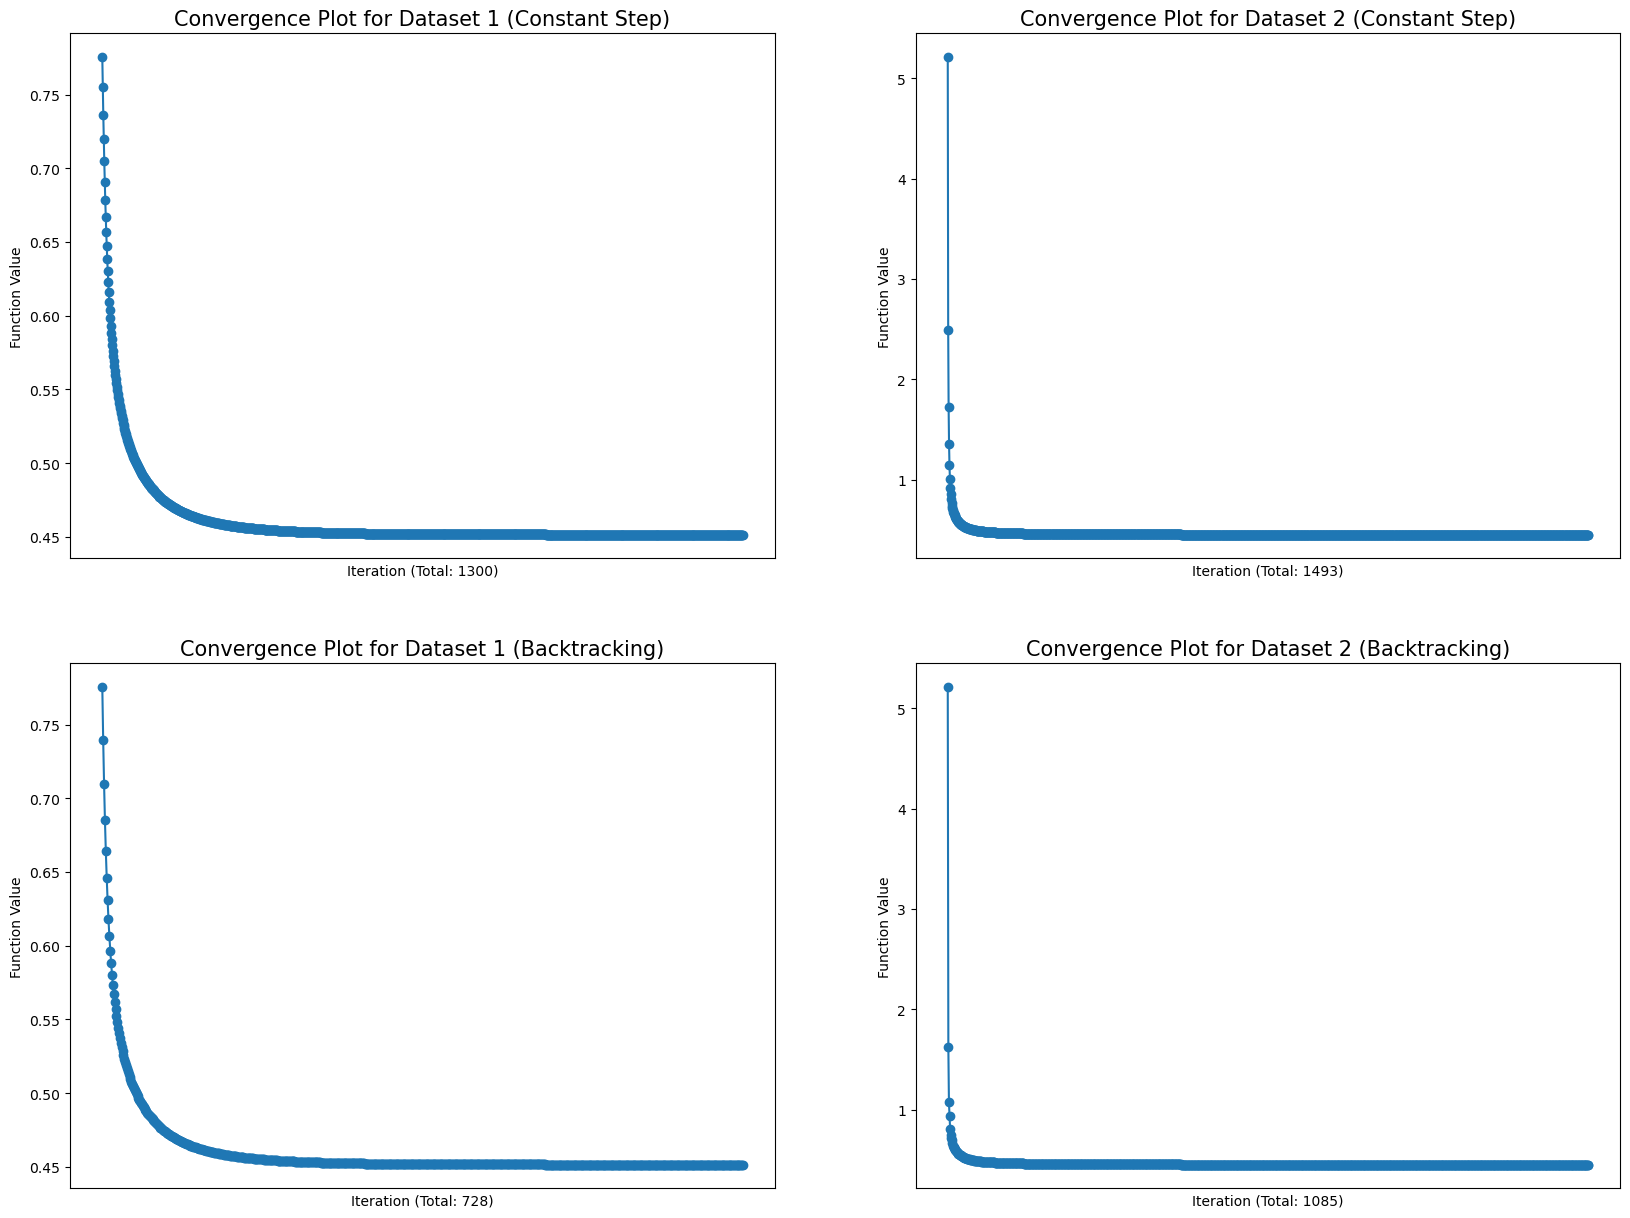

In [154]:
# Convergence Plot
# 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

titles = [
    "Convergence Plot for Dataset 1 (Constant Step)",
    "Convergence Plot for Dataset 2 (Constant Step)",
    "Convergence Plot for Dataset 1 (Backtracking)",
    "Convergence Plot for Dataset 2 (Backtracking)"
]

all_outputs = [
    [loss_fcn(X1, y1, const_points_1[:, i:i+1]) for i in range(const_points_1.shape[1])],
    [loss_fcn(X2, y2, const_points_2[:, i:i+1]) for i in range(const_points_2.shape[1])],
    [loss_fcn(X1, y1, backtracking_points_1[:, i:i+1]) for i in range(backtracking_points_1.shape[1])],
    [loss_fcn(X2, y2, backtracking_points_2[:, i:i+1]) for i in range(backtracking_points_2.shape[1])]
]

iterations = [
    const_points_1.shape[1],
    const_points_2.shape[1],
    backtracking_points_1.shape[1],
    backtracking_points_2.shape[1]
]

for ax, title, outputs, iters in zip(axes.flatten(), titles, all_outputs, iterations):
    
    x_vals = list(range(len(outputs)))  # iterations
    ax.plot(x_vals, outputs, marker='o')
    
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(f"Iteration (Total: {iters})") 
    ax.set_ylabel("Function Value")
    ax.set_xticks([])
    
plt.show()

## CODE (2.b)

#### Polyak Heavy Ball (Constant Step Size)

In [155]:
# Estimate Linear Regression Coefficients with Polyak' Heavy Ball Method (const)
def Polyak(gradient, X, y, step_size):
    # Parameters
    beta0 = np.zeros((X.shape[1], 1))
    tol = 1e-4
    xi = 0.5
    
    # Initial values
    beta = beta0.copy()
    num_iter = 0
    points = beta
    last_velo = np.zeros_like(beta)
    
    while num_iter < 3000:  
        # COMPUTE GRADIENT
        grad = gradient(X, y, beta)
        
        # STOP CRITERION
        if norm2(grad) < tol:
            break
        
        # INCREMENT
        num_iter += 1
        
        # COMPUTE VELOCITY
        velo = xi * last_velo + grad
        last_velo = velo.copy()
        
        # COMPUTE NEW POINT
        beta = beta - step_size * velo
        points = np.hstack((points, beta)) 

    return {"value": beta, "points": points}

#### Nesterov Accelerate Gradient (Constant Step Size)

In [1]:
# Estimate Linear Regression Coefficients with Nesterov's Accelerated Gradient Method (const)
def Nesterov(gradient, X, y, step_size):
    # Parameters
    beta0 = np.zeros((X.shape[1], 1))
    tol = 1e-4
    xi = 0.2
    
    # Initial values
    beta = beta0.copy()
    num_iter = 0
    points = beta
    last_beta = np.zeros_like(beta)
    
    while num_iter < 3000:          
        # INCREMENT
        num_iter += 1
        
        # EXTRAPOLATION
        extrapolate = beta + xi * (beta - last_beta)
        last_beta = beta.copy()

        # COMPUTE GRADIENT
        grad = gradient(X, y, extrapolate)
        
        # STOP CRITERION
        if norm2(grad) < tol:
            break
        
        # COMPUTE NEW POINT
        beta = extrapolate - step_size * grad
        points = np.hstack((points, beta)) 

    return {"value": beta, "points": points}

In [157]:
# Dataset 1 Polyak' Heavy Ball (const)
Polyak_1 = Polyak(gradient, X1, y1, step_size = 40)
Polyak_val_1 = Polyak_1["value"]
Polyak_points_1 = Polyak_1["points"]

# Dataset 2 Polyak' Heavy Ball (const)
Polyak_2 = Polyak(gradient, X2, y2, step_size = 3.3)
Polyak_val_2 = Polyak_2["value"]
Polyak_points_2 = Polyak_2["points"]

# Dataset 1 Nesterov's Accelerated Gradient (const)
Nesterov_1 = Nesterov(gradient, X1, y1, step_size = 40)
Nesterov_val_1 = Nesterov_1["value"]
Nesterov_points_1 = Nesterov_1["points"]

# Dataset 2 Nesterov's Accelerated Gradient (const)
Nesterov_2 = Nesterov(gradient, X2, y2, step_size = 1.5)
Nesterov_val_2 = Nesterov_2["value"]
Nesterov_points_2 = Nesterov_2["points"]

#### Ployak Heavy Ball (Backtracking)

In [158]:
# Estimate Linear Regression Coefficients with Polyak' Heavy Ball Method (const)
def Polyak_back(gradient, X, y):
    # Parameters
    beta0 = np.zeros((X.shape[1], 1))
    tol = 1e-4
    epsilon = 0.25
    tau = 0.5
    xi = 0.5
    
    # Initial values
    beta = beta0
    num_iter = 0
    points = beta
    last_velo = np.zeros_like(beta)
    
    while num_iter < 3000:  
        # COMPUTE GRADIENT
        grad = gradient(X, y, beta)
        loss = loss_fcn(X, y, beta)
        
        # STOP CRITERION
        if norm2(grad) < tol:
            break
        
        # INCREMENT
        num_iter += 1

        # RESET STEP SIZE
        step_size = 5

        # UPDATE (Armijo Condition)
        while loss_fcn(X, y, beta - step_size * grad) > loss - epsilon * step_size * norm2(grad)**2:
            step_size = tau * step_size
        
        # COMPUTE VELOCITY
        velo = xi * last_velo + grad
        last_velo = velo.copy()
        
        # COMPUTE NEW POINT
        beta = beta - step_size * velo
        points = np.hstack((points, beta)) 

    return {"value": beta, "points": points}

#### Nesterov's Accelerated Gradient (Backtracking)

In [159]:
# Estimate Linear Regression Coefficients with Nesterov's Accelerated Gradient Method (const)
def Nesterov_back(gradient, X, y):
    # Parameters
    beta0 = np.zeros((X.shape[1], 1))
    tol = 1e-4
    epsilon = 0.25
    tau = 0.5
    xi = 0.2
    
    # Initial values
    beta = beta0.copy()
    num_iter = 0
    points = beta
    last_beta = np.zeros_like(beta)
    
    while num_iter < 3000:          
        # EXTRAPOLATION
        extrapolate = beta + xi * (beta - last_beta)
        last_beta = beta.copy()

        # COMPUTE GRADIENT
        grad = gradient(X, y, extrapolate)
        loss = loss_fcn(X, y, beta)
        
        # STOP CRITERION
        if norm2(grad) < tol:
            break

        # INCREMENT
        num_iter += 1

        # RESET STEP SIZE
        step_size = 5

        # UPDATE (Armijo Condition)
        while loss_fcn(X, y, beta - step_size * grad) > loss - epsilon * step_size * norm2(grad)**2:
            step_size = tau * step_size
            
        # COMPUTE NEW POINT
        beta = extrapolate - step_size * grad
        points = np.hstack((points, beta)) 

    return {"value": beta, "points": points}

In [160]:
# Dataset 1 Polyak' Heavy Ball (backtracking)
Polyak_back_1 = Polyak_back(gradient, X1, y1)
Polyak_back_val_1 = Polyak_back_1["value"]
Polyak_back_points_1 = Polyak_back_1["points"]

# Dataset 2 Polyak' Heavy Ball (backtracking)
Polyak_back_2 = Polyak_back(gradient, X2, y2)
Polyak_back_val_2 = Polyak_back_2["value"]
Polyak_back_points_2 = Polyak_back_2["points"]

# Dataset 1 Nesterov's Accelerated Gradient (backtracking)
Nesterov_back_1 = Nesterov_back(gradient, X1, y1)
Nesterov_back_val_1 = Nesterov_back_1["value"]
Nesterov_back_points_1 = Nesterov_back_1["points"]

# Dataset 2 Nesterov's Accelerated Gradient (backtracking)
Nesterov_back_2 = Nesterov_back(gradient, X2, y2)
Nesterov_back_val_2 = Nesterov_back_2["value"]
Nesterov_back_points_2 = Nesterov_back_2["points"]

## CODE (2.b.1)

In [161]:
print(f"The L2 error for dataset1 with Polyak's Heavy Ball (const) is {norm2(Polyak_val_1 - beta_ols_1)} with {Polyak_points_1.shape[1]} iterations")
print(f"The L2 error for dataset1 with Nesterov's Accelerated Gradient (const) is {norm2(Nesterov_val_1 - beta_ols_1)} with {Nesterov_points_1.shape[1]} iterations")
print(f"The L2 error for dataset2 with Polyak's Heavy Ball (const) is {norm2(Polyak_val_2 - beta_ols_2)} with {Polyak_points_2.shape[1]} iterations")
print(f"The L2 error for dataset2 with Nesterov's Accelerated Gradient (const) is {norm2(Nesterov_val_2 - beta_ols_2)} with {Nesterov_points_2.shape[1]} iterations")
print(" ")
print(f"The L2 error for dataset1 with Polyak's Heavy Ball (backtracking) is {norm2(Polyak_back_val_1 - beta_ols_1)} with {Polyak_back_points_1.shape[1]} iterations")
print(f"The L2 error for dataset1 with Nesterov's Accelerated Gradient (backtracking) is {norm2(Nesterov_back_val_1 - beta_ols_1)} with {Nesterov_back_points_1.shape[1]} iterations")
print(f"The L2 error for dataset2 with Polyak's Heavy Ball (backtracking) is {norm2(Polyak_back_val_2 - beta_ols_2)} with {Polyak_back_points_2.shape[1]} iterations")
print(f"The L2 error for dataset2 with Nesterov's Accelerated Gradient (backtracking) is {norm2(Nesterov_back_val_2 - beta_ols_2)} with {Nesterov_back_points_2.shape[1]} iterations")

The L2 error for dataset1 with Polyak's Heavy Ball (const) is 0.08507937711790518 with 41 iterations
The L2 error for dataset1 with Nesterov's Accelerated Gradient (const) is 0.08703224544992047 with 72 iterations
The L2 error for dataset2 with Polyak's Heavy Ball (const) is 0.08727904174989319 with 494 iterations
The L2 error for dataset2 with Nesterov's Accelerated Gradient (const) is 0.08731438059971773 with 1751 iterations
 
The L2 error for dataset1 with Polyak's Heavy Ball (backtracking) is 0.0880311266271821 with 360 iterations
The L2 error for dataset1 with Nesterov's Accelerated Gradient (backtracking) is 0.0879291715609226 with 582 iterations
The L2 error for dataset2 with Polyak's Heavy Ball (backtracking) is 0.06584813324503602 with 888 iterations
The L2 error for dataset2 with Nesterov's Accelerated Gradient (backtracking) is 0.0807405381699661 with 1029 iterations


## CODE (2.b.2)

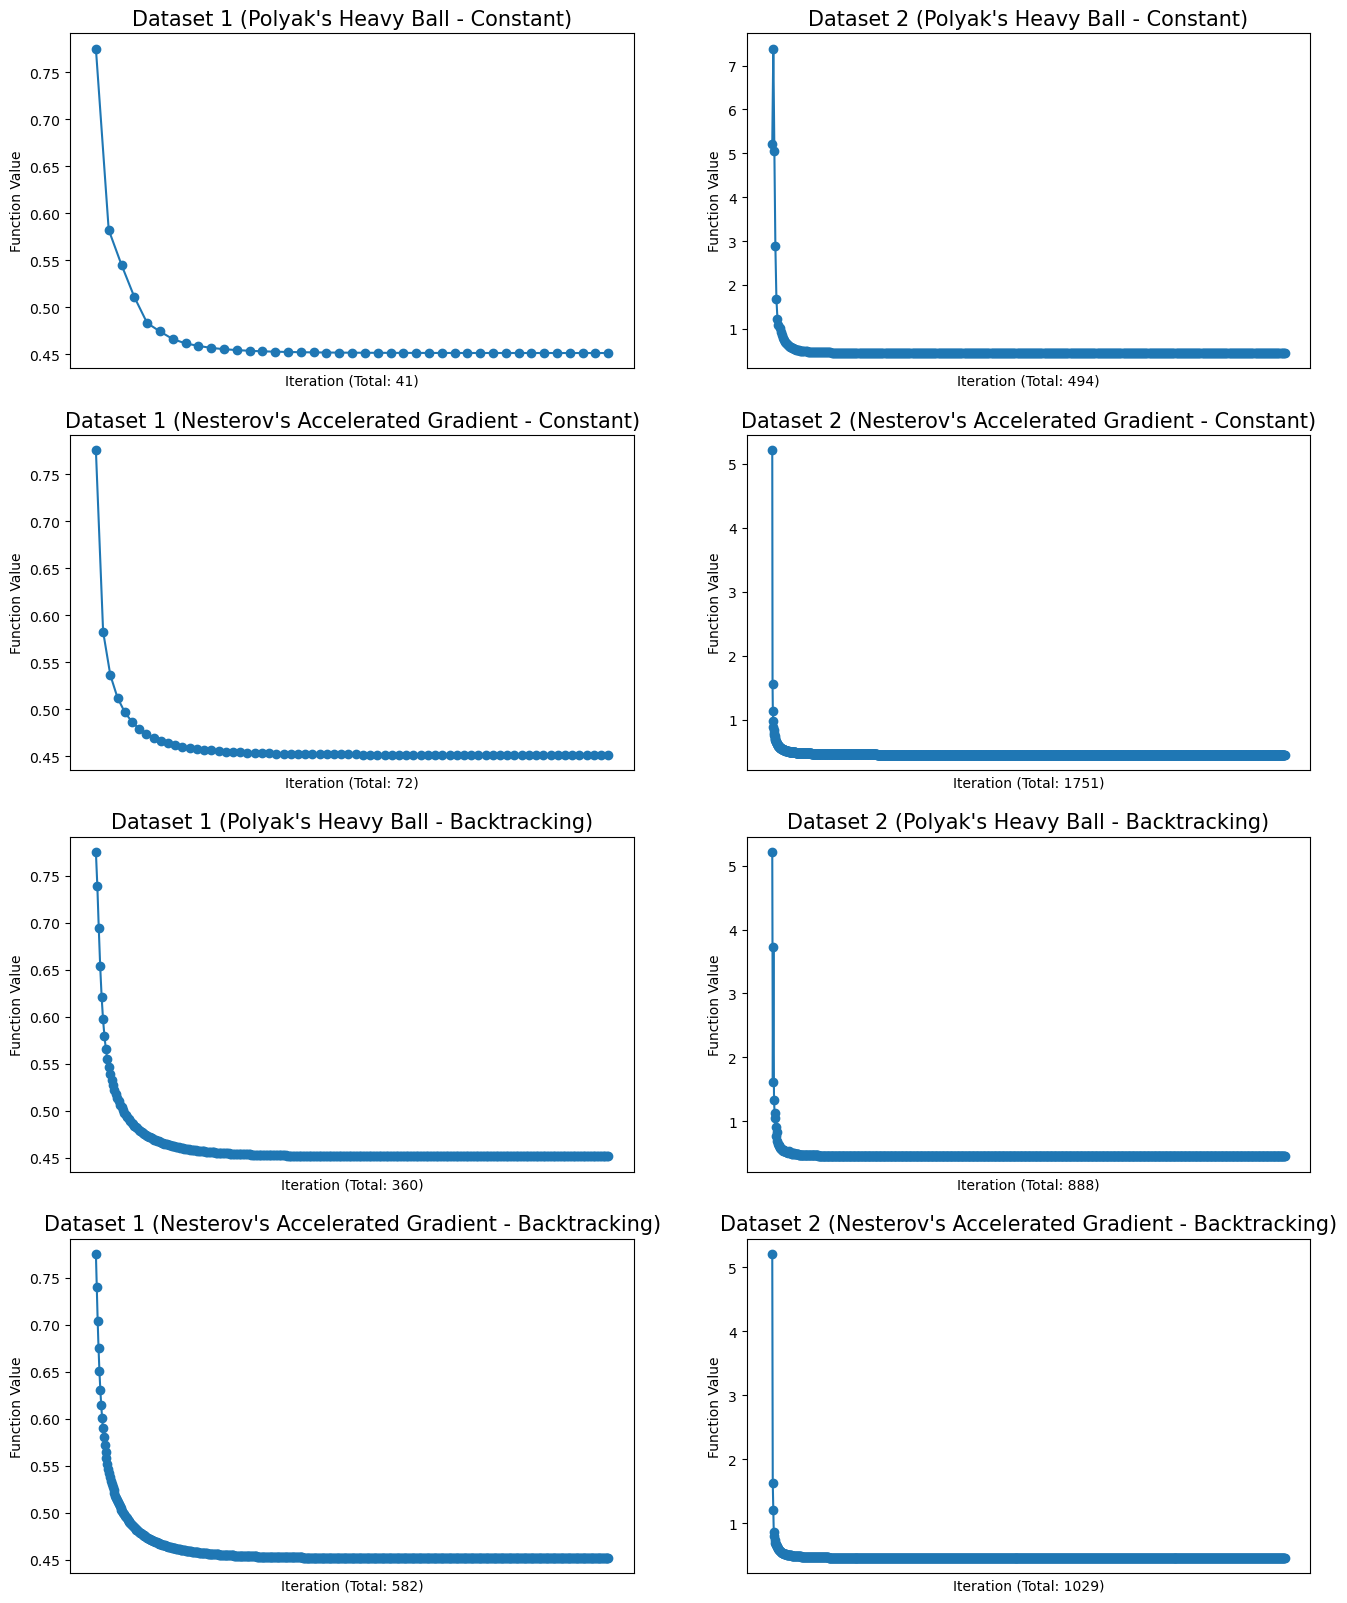

In [162]:
# Convergence Plot
# 4 rows and 2 columns
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

titles = [
    "Dataset 1 (Polyak's Heavy Ball - Constant)",
    "Dataset 2 (Polyak's Heavy Ball - Constant)",
    "Dataset 1 (Nesterov's Accelerated Gradient - Constant)",
    "Dataset 2 (Nesterov's Accelerated Gradient - Constant)",
    "Dataset 1 (Polyak's Heavy Ball - Backtracking)",
    "Dataset 2 (Polyak's Heavy Ball - Backtracking)",
    "Dataset 1 (Nesterov's Accelerated Gradient - Backtracking)",
    "Dataset 2 (Nesterov's Accelerated Gradient - Backtracking)"
]

all_outputs = [
    [loss_fcn(X1, y1, Polyak_points_1[:, i:i+1]) for i in range(Polyak_points_1.shape[1])],
    [loss_fcn(X2, y2, Polyak_points_2[:, i:i+1]) for i in range(Polyak_points_2.shape[1])],
    [loss_fcn(X1, y1, Nesterov_points_1[:, i:i+1]) for i in range(Nesterov_points_1.shape[1])],
    [loss_fcn(X2, y2, Nesterov_points_2[:, i:i+1]) for i in range(Nesterov_points_2.shape[1])],
    [loss_fcn(X1, y1, Polyak_back_points_1[:, i:i+1]) for i in range(Polyak_back_points_1.shape[1])],
    [loss_fcn(X2, y2, Polyak_back_points_2[:, i:i+1]) for i in range(Polyak_back_points_2.shape[1])],
    [loss_fcn(X1, y1, Nesterov_back_points_1[:, i:i+1]) for i in range(Nesterov_back_points_1.shape[1])],
    [loss_fcn(X2, y2, Nesterov_back_points_2[:, i:i+1]) for i in range(Nesterov_back_points_2.shape[1])]
]

iterations = [
    Polyak_points_1.shape[1],
    Polyak_points_2.shape[1],
    Nesterov_points_1.shape[1],
    Nesterov_points_2.shape[1],
    Polyak_back_points_1.shape[1],
    Polyak_back_points_2.shape[1],
    Nesterov_back_points_1.shape[1],
    Nesterov_back_points_2.shape[1],
]

for ax, title, outputs, iters in zip(axes.flatten(), titles, all_outputs, iterations):
    
    x_vals = list(range(len(outputs)))  # iterations
    ax.plot(x_vals, outputs, marker='o')
    
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(f"Iteration (Total: {iters})") 
    ax.set_ylabel("Function Value")
    ax.set_xticks([])
    
plt.show()